# Heart Disease Prediction
# Phase 5 — Wrapper Feature Selection
### UCI Cleveland Heart Disease Dataset
---
**Continues from:** `04_baseline_training.py`

**What is Wrapper Feature Selection?**

Wrapper methods select features by **training and evaluating a model** on different subsets of features.
Unlike Filter methods (which rank features using statistics alone), Wrapper methods actually use a model
to judge which features are useful — making them more accurate but more computationally expensive.

Think of it like this:
- 🔵 **Filter** = teacher scores features before class using pure statistics — no model involved
- 🟡 **Wrapper** = trial and error — train a model on different feature subsets and keep the best
- 🟢 **Embedded** = the model itself learns to ignore useless features while it trains

**Four Wrapper Methods used here:**
1. **RFE (Recursive Feature Elimination)** — removes the weakest feature one-by-one until target count reached
2. **RFECV (RFE with Cross-Validation)** — same as RFE but automatically finds the optimal number of features
3. **Forward Selection** — starts with no features and adds the best one at each step
4. **Backward Elimination** — starts with all features and removes the weakest one at each step

**Goal:** Find the best subset of features using each method → retrain all 8 models → compare with Baseline

---
## Cell 1 — Install & Import Libraries

In [2]:
# ============================================================
# CELL 1 — Install & Import All Required Libraries
# ============================================================

!pip install xgboost mlxtend seaborn --quiet

# --- Core libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# --- Wrapper Feature Selection tools ---
from sklearn.feature_selection import RFE, RFECV            # RFE and RFECV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS  # Forward & Backward

# --- The 8 Models (same as Baseline) ---
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from xgboost                 import XGBClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.neural_network  import MLPClassifier

# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# --- Plot settings ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('=' * 55)
print('   All libraries imported successfully!')
print('=' * 55)

   All libraries imported successfully!


---
## Cell 2 — Load Preprocessed Data

> We load the exact same preprocessed data saved by `03_preprocessing.py`.
> This guarantees our feature selection experiment starts from the same point as the Baseline.

In [3]:
# ============================================================
# CELL 2 — Load Preprocessed Data from saved_data/
# ============================================================

LOAD_DIR = 'saved_data'

# Scaled versions → used for models that need scaling (LR, SVM, KNN, MLP)
X_train_scaled = joblib.load(f'{LOAD_DIR}/X_train_scaled.pkl')
X_test_scaled  = joblib.load(f'{LOAD_DIR}/X_test_scaled.pkl')

# Raw (unscaled) versions → used for tree-based models (DT, RF, XGB)
X_train_raw    = joblib.load(f'{LOAD_DIR}/X_train_raw.pkl')
X_test_raw     = joblib.load(f'{LOAD_DIR}/X_test_raw.pkl')

# Labels
y_train        = joblib.load(f'{LOAD_DIR}/y_train.pkl')
y_test         = joblib.load(f'{LOAD_DIR}/y_test.pkl')

# Feature names (after One-Hot Encoding)
feature_names  = joblib.load(f'{LOAD_DIR}/feature_names.pkl')

# Baseline results (to compare against later)
baseline_results = joblib.load(f'{LOAD_DIR}/baseline_results.pkl')

# Convert to proper pandas objects
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names) if not isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names) if not isinstance(X_test_scaled,  pd.DataFrame) else X_test_scaled
X_train_raw    = pd.DataFrame(X_train_raw,    columns=feature_names) if not isinstance(X_train_raw,    pd.DataFrame) else X_train_raw
X_test_raw     = pd.DataFrame(X_test_raw,     columns=feature_names) if not isinstance(X_test_raw,     pd.DataFrame) else X_test_raw
y_train        = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train
y_test         = pd.Series(y_test)  if not isinstance(y_test,  pd.Series) else y_test

# Reset indices
for df in [X_train_scaled, X_test_scaled, X_train_raw, X_test_raw]:
    df.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print('Data loaded successfully!')
print(f'  X_train_scaled : {X_train_scaled.shape}')
print(f'  X_test_scaled  : {X_test_scaled.shape}')
print(f'  X_train_raw    : {X_train_raw.shape}')
print(f'  X_test_raw     : {X_test_raw.shape}')
print(f'  y_train classes: {y_train.value_counts().to_dict()}')
print(f'  y_test  classes: {y_test.value_counts().to_dict()}')
print(f'  Total features : {len(feature_names)}')
print(f'  Feature names  : {feature_names}')

Data loaded successfully!
  X_train_scaled : (262, 22)
  X_test_scaled  : (61, 22)
  X_train_raw    : (262, 22)
  X_test_raw     : (61, 22)
  y_train classes: {1: 131, 0: 131}
  y_test  classes: {0: 33, 1: 28}
  Total features : 22
  Feature names  : ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_4', 'thal_5', 'thal_6', 'thal_7', 'ca_1', 'ca_2', 'ca_3']


---
## Cell 3 — Define the 8 Models

> The same 8 models used in the Baseline phase are defined here.
> **Note:** RFE requires models that expose feature importance (via `coef_` or `feature_importances_`).
> Models like KNN and Naive Bayes do not support RFE directly, so we use Logistic Regression as
> the RFE estimator for them, then train them on the selected features afterward.

In [4]:
# ============================================================
# CELL 3 — Define All 8 Models
# ============================================================

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='linear', probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(),
    'Naive Bayes'         : GaussianNB(),
    'Neural Network (MLP)': MLPClassifier(max_iter=1000, random_state=42),
    'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42)
}

# Models that support RFE directly (have coef_ or feature_importances_)
rfe_compatible = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='linear', probability=True, random_state=42),
    'XGBoost'             : XGBClassifier(eval_metric='logloss', random_state=42)
}

# Proxy estimator for models that do NOT support RFE (KNN, NB, MLP)
rfe_proxy = LogisticRegression(max_iter=1000, random_state=42)

N_FEATURES = 8   # Target number of features to select (RFE, Forward, Backward)

print(f'  Models defined  : {len(models)}')
print(f'  RFE-compatible  : {list(rfe_compatible.keys())}')
print(f'  Target features : {N_FEATURES}')

  Models defined  : 8
  RFE-compatible  : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost']
  Target features : 8


---
## Cell 4 — Method 1: RFE (Recursive Feature Elimination)

### What is RFE?

**Recursive Feature Elimination (RFE)** is a wrapper method that works by:
1. Training a model on all features
2. Ranking features by their importance (using `coef_` or `feature_importances_`)
3. Removing the least important feature
4. Repeating until the desired number of features remains

**Key parameter:** `n_features_to_select` — how many features to keep (we use 8 here).

**Why is this a Wrapper method?**  
Because it trains the model at each elimination step — it wraps around the model and uses it
to score features, not just statistics.

In [5]:
# ============================================================
# CELL 4 — Method 1: RFE (Recursive Feature Elimination)
# ============================================================

print('METHOD 1: RFE — Recursive Feature Elimination')
print('=' * 60)

rfe_results        = {}   # accuracy per model
rfe_features_dict  = {}   # selected feature names per model
rfe_metrics_dict   = {}   # full metrics per model

for name, model in models.items():

    # Choose the correct data version
    X_tr = X_train_scaled if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_train_raw
    X_te = X_test_scaled  if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_test_raw

    # Use model itself if RFE-compatible, otherwise use proxy (LR)
    estimator = rfe_compatible[name] if name in rfe_compatible else rfe_proxy

    # Apply RFE
    rfe = RFE(estimator=estimator, n_features_to_select=N_FEATURES)
    X_tr_rfe = rfe.fit_transform(X_tr, y_train)
    X_te_rfe = rfe.transform(X_te)

    # Get selected feature names
    selected = list(np.array(feature_names)[rfe.support_])
    rfe_features_dict[name] = selected

    # Train the actual model on selected features
    model.fit(X_tr_rfe, y_train)
    y_pred      = model.predict(X_te_rfe)
    y_pred_proba = model.predict_proba(X_te_rfe)[:, 1] if hasattr(model, 'predict_proba') else None

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    rfe_results[name] = acc
    rfe_metrics_dict[name] = {
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1'       : round(f1_score(y_test, y_pred) * 100, 2),
        'AUC'      : round(roc_auc_score(y_test, y_pred_proba) * 100, 2) if y_pred_proba is not None else None
    }

    print(f'\n  {name}')
    print(f'    Accuracy  : {acc*100:.2f}%')
    print(f'    Selected  : {selected}')

print('\n' + '=' * 60)
print('  ✅ RFE complete!')

METHOD 1: RFE — Recursive Feature Elimination

  Logistic Regression
    Accuracy  : 88.52%
    Selected  : [np.str_('sex'), np.str_('oldpeak'), np.str_('cp_4.0'), np.str_('slope_2.0'), np.str_('thal_7'), np.str_('ca_1'), np.str_('ca_2'), np.str_('ca_3')]

  Decision Tree
    Accuracy  : 67.21%
    Selected  : [np.str_('age'), np.str_('sex'), np.str_('trestbps'), np.str_('chol'), np.str_('thalach'), np.str_('oldpeak'), np.str_('cp_4.0'), np.str_('thal_7')]

  Random Forest
    Accuracy  : 88.52%
    Selected  : [np.str_('age'), np.str_('sex'), np.str_('trestbps'), np.str_('chol'), np.str_('thalach'), np.str_('oldpeak'), np.str_('cp_4.0'), np.str_('thal_7')]

  SVM
    Accuracy  : 85.25%
    Selected  : [np.str_('sex'), np.str_('oldpeak'), np.str_('cp_3.0'), np.str_('cp_4.0'), np.str_('slope_2.0'), np.str_('thal_7'), np.str_('ca_1'), np.str_('ca_3')]

  KNN
    Accuracy  : 81.97%
    Selected  : [np.str_('sex'), np.str_('oldpeak'), np.str_('cp_4.0'), np.str_('slope_2.0'), np.str_('thal_

---
## Cell 5 — Visualize RFE: Feature Selection Heatmap

> This heatmap shows which features were selected by RFE for each model.
> A **green cell** means the feature was selected; a **red cell** means it was eliminated.
> Features selected by more models are more universally important.

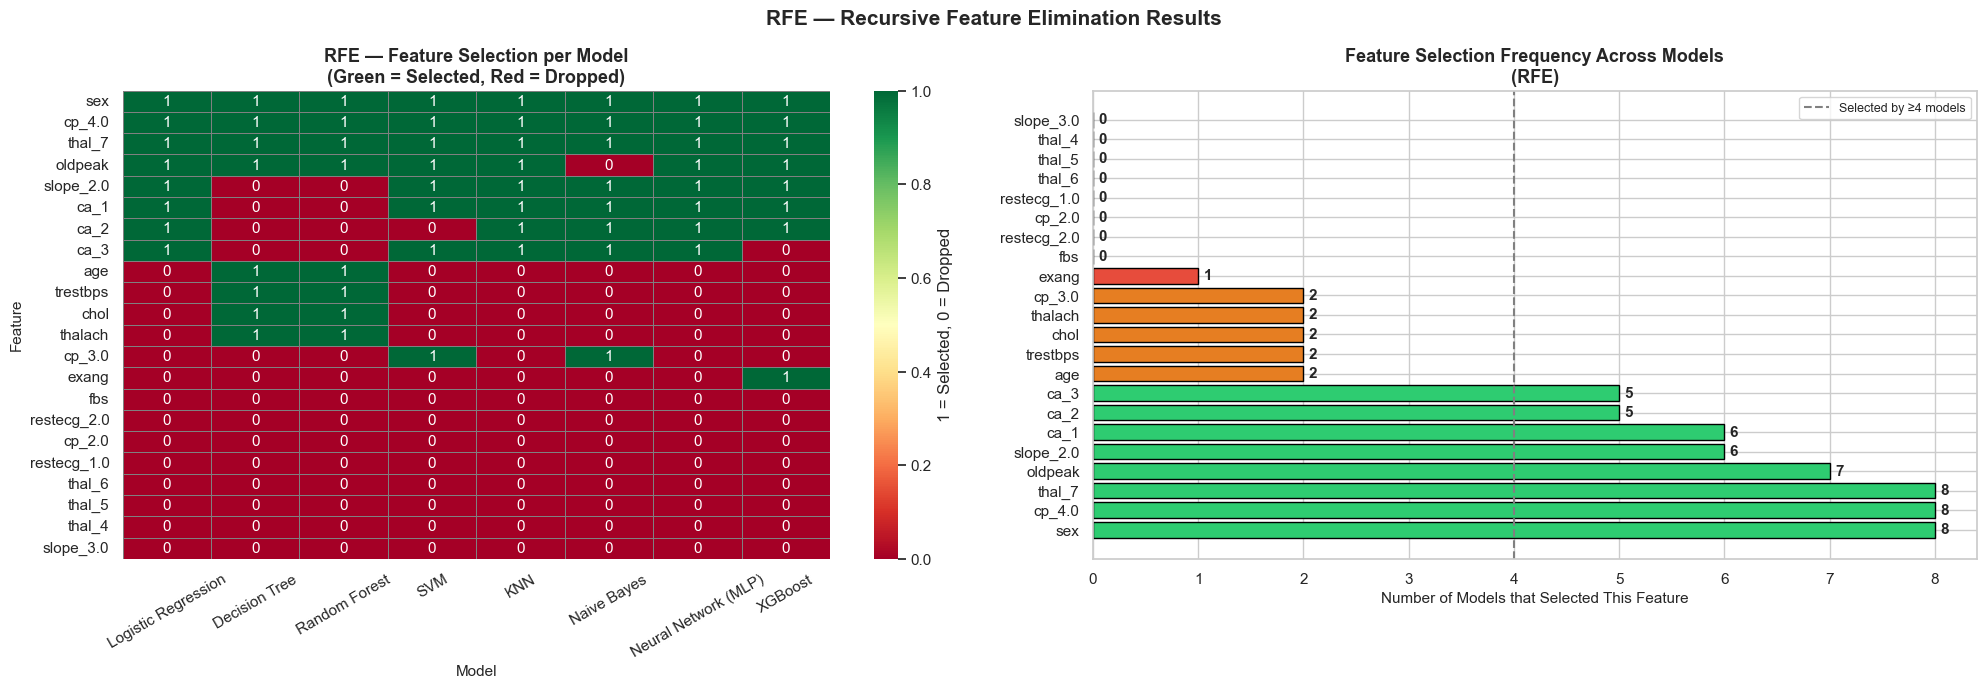

   RFE heatmap saved!


In [6]:
# ============================================================
# CELL 5 — RFE: Feature Selection Heatmap
# ============================================================

# Build binary matrix: 1 = selected, 0 = not selected
rfe_matrix = pd.DataFrame(
    {name: [1 if f in rfe_features_dict[name] else 0 for f in feature_names]
     for name in models.keys()},
    index=feature_names
)
rfe_matrix['Selection Count'] = rfe_matrix.sum(axis=1)
rfe_matrix = rfe_matrix.sort_values('Selection Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Plot 1: Heatmap ---
sns.heatmap(
    rfe_matrix.drop(columns='Selection Count'),
    ax=axes[0], cmap='RdYlGn', linewidths=0.5,
    linecolor='gray', annot=True, fmt='d',
    cbar_kws={'label': '1 = Selected, 0 = Dropped'}
)
axes[0].set_title('RFE — Feature Selection per Model\n(Green = Selected, Red = Dropped)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Model', fontsize=11)
axes[0].set_ylabel('Feature', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# --- Plot 2: Selection frequency bar chart ---
freq = rfe_matrix['Selection Count']
colors = ['#2ecc71' if v >= 4 else '#e67e22' if v >= 2 else '#e74c3c' for v in freq.values]
bars = axes[1].barh(freq.index, freq.values, color=colors, edgecolor='black')
axes[1].axvline(4, color='gray', linestyle='--', linewidth=1.5, label='Selected by ≥4 models')
axes[1].set_xlabel('Number of Models that Selected This Feature', fontsize=11)
axes[1].set_title('Feature Selection Frequency Across Models\n(RFE)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, freq.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(int(val)), va='center', fontweight='bold')

plt.suptitle('RFE — Recursive Feature Elimination Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wrapper_rfe_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('   RFE heatmap saved!')

---
## Cell 6 — Method 2: RFECV (RFE with Cross-Validation)

### What is RFECV?

**RFECV** is an extension of RFE that **automatically determines** the optimal number of features
using cross-validation, rather than requiring you to specify it manually.

**How it works:**
1. Performs RFE at every possible feature count (from 1 to all features)
2. Uses **cross-validation** to score accuracy at each count
3. Automatically selects the feature count with the **highest CV score**

**Why is this better than plain RFE?**  
Plain RFE requires you to guess how many features to keep. RFECV removes this guesswork
by letting cross-validation find the data-driven optimal number automatically.

> ⚠️ RFECV is slower than RFE because it runs CV at every possible feature count.
> We use Logistic Regression as the estimator for all models to keep runtime reasonable.

In [6]:
# ============================================================
# CELL 6 — Method 2: RFECV (RFE with Cross-Validation)
# ============================================================

print('METHOD 2: RFECV — RFE with Cross-Validation')
print('=' * 60)

# We run RFECV once with LR estimator to find the optimal features
# then retrain all 8 models on those features

rfecv_estimator = LogisticRegression(max_iter=1000, random_state=42)
cv_strategy     = StratifiedKFold(n_splits=5)

rfecv = RFECV(
    estimator   = rfecv_estimator,
    step        = 1,
    cv          = cv_strategy,
    scoring     = 'accuracy',
    min_features_to_select = 1
)
rfecv.fit(X_train_scaled, y_train)

rfecv_selected_features = list(np.array(feature_names)[rfecv.support_])
rfecv_n_features        = rfecv.n_features_

print(f'\n  Optimal number of features : {rfecv_n_features}')
print(f'  Selected features          : {rfecv_selected_features}')

# Now train all 8 models on the RFECV-selected features
rfecv_results      = {}
rfecv_metrics_dict = {}

for name, model in models.items():
    X_tr = X_train_scaled[rfecv_selected_features] if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_train_raw[rfecv_selected_features]
    X_te = X_test_scaled[rfecv_selected_features]  if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_test_raw[rfecv_selected_features]

    model.fit(X_tr, y_train)
    y_pred       = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    rfecv_results[name] = acc
    rfecv_metrics_dict[name] = {
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1'       : round(f1_score(y_test, y_pred) * 100, 2),
        'AUC'      : round(roc_auc_score(y_test, y_pred_proba) * 100, 2) if y_pred_proba is not None else None
    }

    print(f'  {name:25s} → Accuracy: {acc*100:.2f}%')

print('\n' + '=' * 60)
print('  ✅ RFECV complete!')

METHOD 2: RFECV — RFE with Cross-Validation

  Optimal number of features : 18
  Selected features          : [np.str_('sex'), np.str_('trestbps'), np.str_('chol'), np.str_('fbs'), np.str_('thalach'), np.str_('exang'), np.str_('oldpeak'), np.str_('cp_2.0'), np.str_('cp_3.0'), np.str_('cp_4.0'), np.str_('restecg_1.0'), np.str_('restecg_2.0'), np.str_('slope_2.0'), np.str_('thal_4'), np.str_('thal_7'), np.str_('ca_1'), np.str_('ca_2'), np.str_('ca_3')]
  Logistic Regression       → Accuracy: 86.89%
  Decision Tree             → Accuracy: 77.05%
  Random Forest             → Accuracy: 90.16%
  SVM                       → Accuracy: 86.89%
  KNN                       → Accuracy: 83.61%
  Naive Bayes               → Accuracy: 81.97%
  Neural Network (MLP)      → Accuracy: 81.97%
  XGBoost                   → Accuracy: 85.25%

  ✅ RFECV complete!


---
## Cell 7 — Visualize RFECV: Optimal Feature Count Curve

> This plot shows how cross-validation accuracy changes as the number of features increases.
> The **peak** of the curve is where RFECV automatically selected to stop — the optimal feature count.

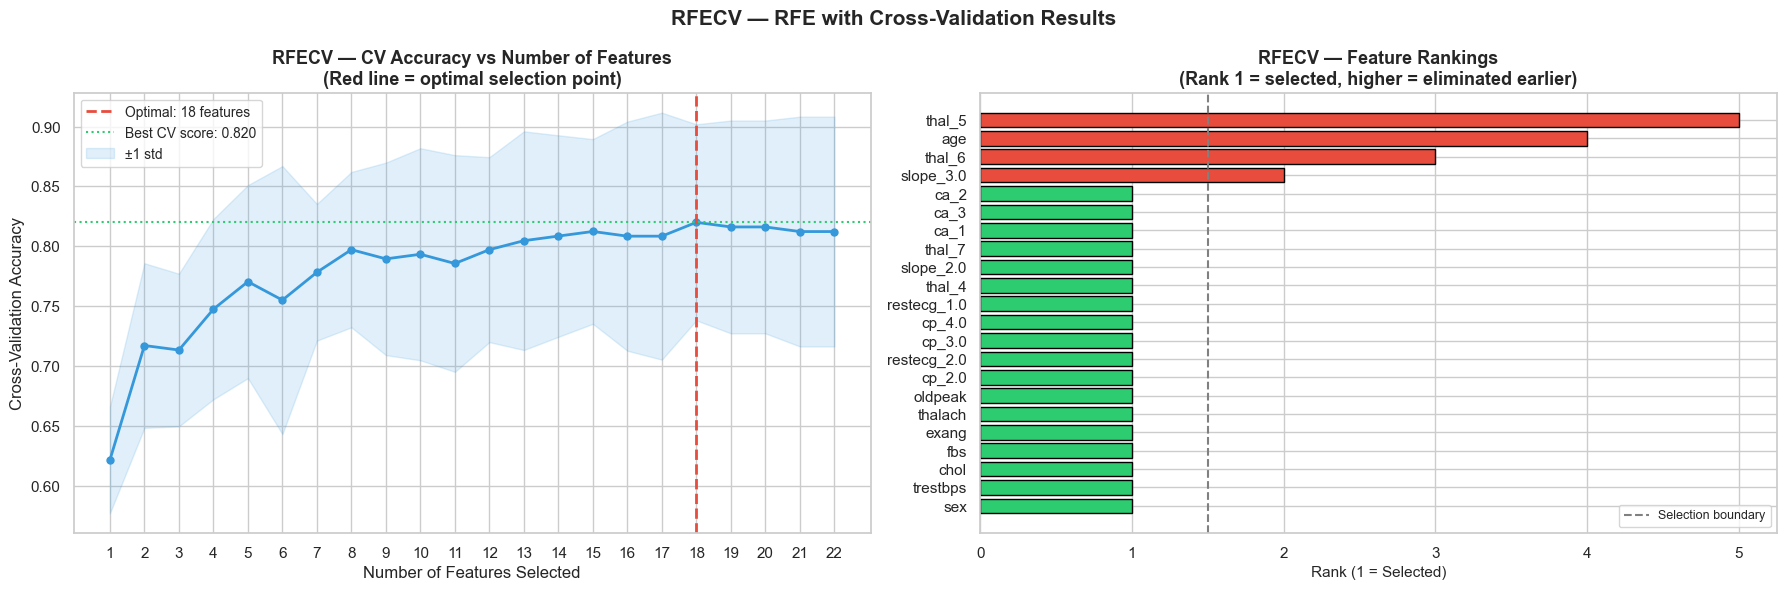

   RFECV visualization saved!


In [8]:
# ============================================================
# CELL 7 — RFECV: Cross-Validation Score Curve
# ============================================================

# Extract CV scores at each feature count
cv_scores = rfecv.cv_results_['mean_test_score']
n_range   = range(1, len(cv_scores) + 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: CV Score vs Number of Features ---
axes[0].plot(n_range, cv_scores, marker='o', color='#3498db', linewidth=2, markersize=5)
axes[0].axvline(rfecv_n_features, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Optimal: {rfecv_n_features} features')
axes[0].axhline(max(cv_scores), color='#2ecc71', linestyle=':', linewidth=1.5,
                label=f'Best CV score: {max(cv_scores):.3f}')
axes[0].fill_between(n_range, cv_scores - rfecv.cv_results_['std_test_score'],
                     cv_scores + rfecv.cv_results_['std_test_score'],
                     alpha=0.15, color='#3498db', label='±1 std')
axes[0].set_xlabel('Number of Features Selected', fontsize=12)
axes[0].set_ylabel('Cross-Validation Accuracy', fontsize=12)
axes[0].set_title('RFECV — CV Accuracy vs Number of Features\n(Red line = optimal selection point)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xticks(list(n_range))

# --- Plot 2: Selected features importance ranking ---
rfecv_rank = pd.Series(rfecv.ranking_, index=feature_names).sort_values()
colors_rfecv = ['#2ecc71' if r == 1 else '#e74c3c' for r in rfecv_rank.values]
axes[1].barh(rfecv_rank.index, rfecv_rank.values, color=colors_rfecv, edgecolor='black')
axes[1].set_xlabel('Rank (1 = Selected)', fontsize=11)
axes[1].set_title('RFECV — Feature Rankings\n(Rank 1 = selected, higher = eliminated earlier)',
                  fontsize=13, fontweight='bold')
axes[1].axvline(1.5, color='gray', linestyle='--', linewidth=1.5, label='Selection boundary')
axes[1].legend(fontsize=9)

plt.suptitle('RFECV — RFE with Cross-Validation Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wrapper_rfecv_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('   RFECV visualization saved!')

---
## Cell 8 — Method 3: Forward Selection

### What is Forward Selection?

**Forward Selection** is a greedy search that builds the feature subset from scratch:
1. Start with **zero features**
2. Try adding each remaining feature one at a time
3. Add the feature that gives the **biggest accuracy improvement**
4. Repeat until the desired number of features is reached

**Key idea:** We never remove a feature once added — we only move forward.

**Advantage:** Computationally efficient compared to exhaustive search.  
**Limitation:** Because we never remove, a feature added early may become redundant
once better features are added — this is called the **nesting problem**.

> We use `mlxtend`'s `SequentialFeatureSelector` with `forward=True`.

In [7]:
# ============================================================
# CELL 8 — Method 3: Forward Selection
# ============================================================

print('METHOD 3: Forward Selection')
print('=' * 60)

# Run Forward Selection using LR as estimator to find optimal features
fwd_estimator = LogisticRegression(max_iter=1000, random_state=42)

sfs_fwd = SFS(
    estimator   = fwd_estimator,
    k_features  = N_FEATURES,
    forward     = True,
    floating    = False,
    scoring     = 'accuracy',
    cv          = 5,
    verbose     = 0
)
sfs_fwd.fit(X_train_scaled, y_train)

fwd_selected_idx      = list(sfs_fwd.k_feature_idx_)
fwd_selected_features = list(np.array(feature_names)[fwd_selected_idx])

print(f'  Selected {len(fwd_selected_features)} features: {fwd_selected_features}')

# Retrain all 8 models on Forward-selected features
fwd_results      = {}
fwd_metrics_dict = {}

for name, model in models.items():
    X_tr = X_train_scaled[fwd_selected_features] if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_train_raw[fwd_selected_features]
    X_te = X_test_scaled[fwd_selected_features]  if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_test_raw[fwd_selected_features]

    model.fit(X_tr, y_train)
    y_pred       = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    fwd_results[name] = acc
    fwd_metrics_dict[name] = {
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1'       : round(f1_score(y_test, y_pred) * 100, 2),
        'AUC'      : round(roc_auc_score(y_test, y_pred_proba) * 100, 2) if y_pred_proba is not None else None
    }

    print(f'  {name:25s} → Accuracy: {acc*100:.2f}%')

print('\n' + '=' * 60)
print('  ✅ Forward Selection complete!')

METHOD 3: Forward Selection
  Selected 8 features: [np.str_('age'), np.str_('sex'), np.str_('chol'), np.str_('thalach'), np.str_('cp_4.0'), np.str_('restecg_1.0'), np.str_('slope_2.0'), np.str_('ca_3')]
  Logistic Regression       → Accuracy: 75.41%
  Decision Tree             → Accuracy: 81.97%
  Random Forest             → Accuracy: 78.69%
  SVM                       → Accuracy: 78.69%
  KNN                       → Accuracy: 77.05%
  Naive Bayes               → Accuracy: 62.30%
  Neural Network (MLP)      → Accuracy: 72.13%
  XGBoost                   → Accuracy: 78.69%

  ✅ Forward Selection complete!


---
## Cell 9 — Visualize Forward Selection: Step-by-Step Accuracy Curve

> This chart shows how accuracy improves as each feature is added one by one.
> Each step represents one feature being included in the model.
> The curve flattening is a sign that adding more features provides diminishing returns.

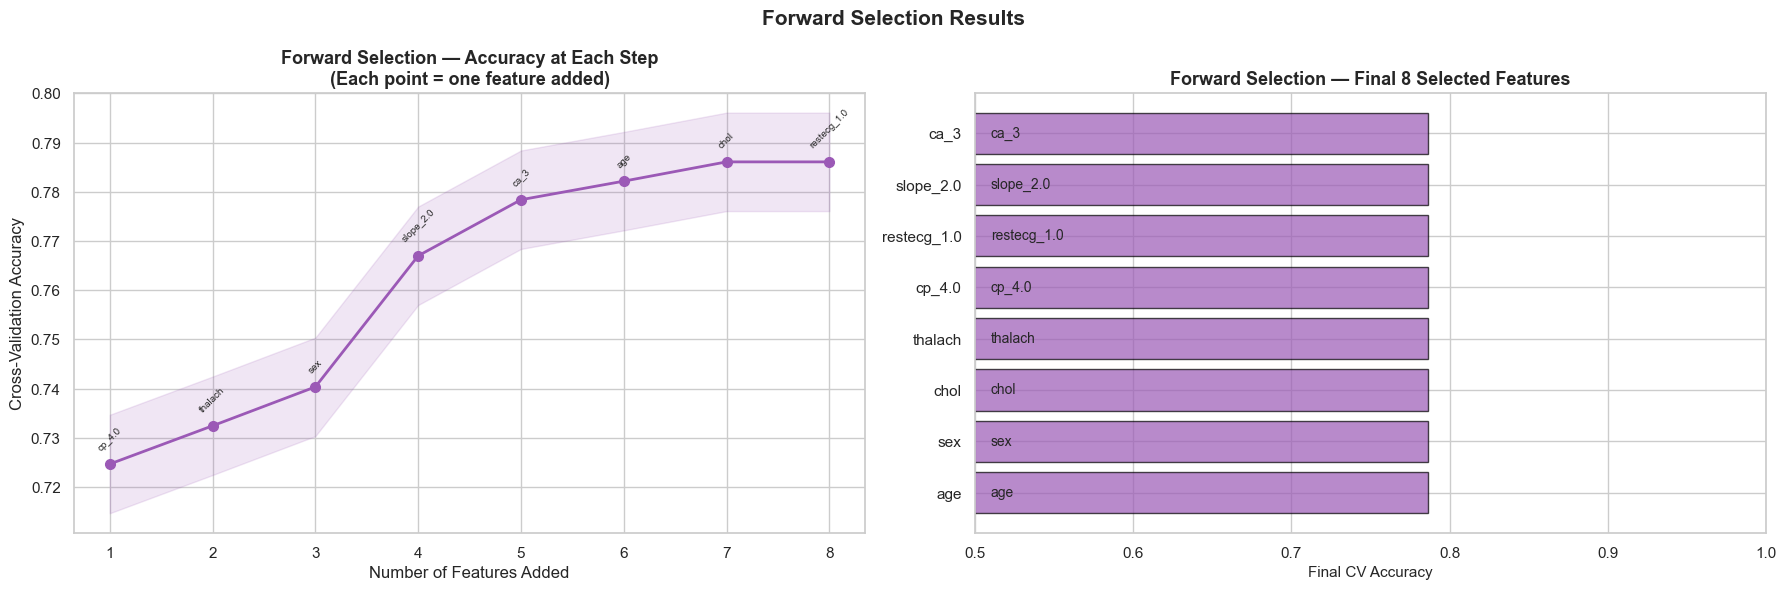

   Forward Selection visualization saved!


In [10]:
# ============================================================
# CELL 9 — Forward Selection: Step-by-Step Accuracy Curve
# ============================================================

# Extract per-step CV scores and feature names from SFS
fwd_steps   = sorted(sfs_fwd.subsets_.keys())
fwd_scores  = [sfs_fwd.subsets_[k]['avg_score'] for k in fwd_steps]
fwd_feat_at_step = [list(np.array(feature_names)[list(sfs_fwd.subsets_[k]['feature_idx'])]) for k in fwd_steps]
fwd_added   = [fwd_feat_at_step[0][0]] + [
    list(set(fwd_feat_at_step[i]) - set(fwd_feat_at_step[i-1]))[0]
    for i in range(1, len(fwd_feat_at_step))
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Step-by-step accuracy ---
axes[0].plot(fwd_steps, fwd_scores, marker='o', color='#9b59b6', linewidth=2, markersize=7)
axes[0].fill_between(fwd_steps, [s - 0.01 for s in fwd_scores],
                     [s + 0.01 for s in fwd_scores], alpha=0.15, color='#9b59b6')
for i, (step, score) in enumerate(zip(fwd_steps, fwd_scores)):
    axes[0].annotate(fwd_added[i], (step, score),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=7, rotation=45)
axes[0].set_xlabel('Number of Features Added', fontsize=12)
axes[0].set_ylabel('Cross-Validation Accuracy', fontsize=12)
axes[0].set_title('Forward Selection — Accuracy at Each Step\n(Each point = one feature added)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(fwd_steps)

# --- Plot 2: Final selected features ---
axes[1].barh(fwd_selected_features,
             [fwd_scores[-1]] * len(fwd_selected_features),
             color='#9b59b6', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Final CV Accuracy', fontsize=11)
axes[1].set_title(f'Forward Selection — Final {N_FEATURES} Selected Features',
                  fontsize=13, fontweight='bold')
axes[1].set_xlim(0.5, 1.0)
for i, feat in enumerate(fwd_selected_features):
    axes[1].text(0.51, i, feat, va='center', fontsize=10)

plt.suptitle('Forward Selection Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wrapper_forward_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Forward Selection visualization saved!')

---
## Cell 10 — Method 4: Backward Elimination

### What is Backward Elimination?

**Backward Elimination** is the opposite of Forward Selection:
1. Start with **all features**
2. Try removing each feature one at a time
3. Remove the feature whose removal causes the **least drop in accuracy**
4. Repeat until only the desired number of features remains

**Key idea:** We never add a feature back once removed — we only move backward.

**Advantage:** Starts from the full picture — all feature interactions are considered at first.  
**Limitation:** More expensive than Forward Selection (starts with all features).
Also suffers from the nesting problem in the opposite direction.

> We use `mlxtend`'s `SequentialFeatureSelector` with `forward=False`.

In [8]:
# ============================================================
# CELL 10 — Method 4: Backward Elimination
# ============================================================

print('METHOD 4: Backward Elimination')
print('=' * 60)

bwd_estimator = LogisticRegression(max_iter=1000, random_state=42)

sfs_bwd = SFS(
    estimator   = bwd_estimator,
    k_features  = N_FEATURES,
    forward     = False,
    floating    = False,
    scoring     = 'accuracy',
    cv          = 5,
    verbose     = 0
)
sfs_bwd.fit(X_train_scaled, y_train)

bwd_selected_idx      = list(sfs_bwd.k_feature_idx_)
bwd_selected_features = list(np.array(feature_names)[bwd_selected_idx])

print(f'  Selected {len(bwd_selected_features)} features: {bwd_selected_features}')

# Retrain all 8 models on Backward-selected features
bwd_results      = {}
bwd_metrics_dict = {}

for name, model in models.items():
    X_tr = X_train_scaled[bwd_selected_features] if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_train_raw[bwd_selected_features]
    X_te = X_test_scaled[bwd_selected_features]  if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_test_raw[bwd_selected_features]

    model.fit(X_tr, y_train)
    y_pred       = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    bwd_results[name] = acc
    bwd_metrics_dict[name] = {
        'Accuracy' : round(acc * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
        'F1'       : round(f1_score(y_test, y_pred) * 100, 2),
        'AUC'      : round(roc_auc_score(y_test, y_pred_proba) * 100, 2) if y_pred_proba is not None else None
    }

    print(f'  {name:25s} → Accuracy: {acc*100:.2f}%')

print('\n' + '=' * 60)
print('  ✅ Backward Elimination complete!')

METHOD 4: Backward Elimination
  Selected 8 features: [np.str_('sex'), np.str_('trestbps'), np.str_('oldpeak'), np.str_('cp_3.0'), np.str_('slope_2.0'), np.str_('slope_3.0'), np.str_('thal_7'), np.str_('ca_1')]
  Logistic Regression       → Accuracy: 86.89%
  Decision Tree             → Accuracy: 70.49%
  Random Forest             → Accuracy: 83.61%
  SVM                       → Accuracy: 85.25%
  KNN                       → Accuracy: 85.25%
  Naive Bayes               → Accuracy: 86.89%
  Neural Network (MLP)      → Accuracy: 80.33%
  XGBoost                   → Accuracy: 80.33%

  ✅ Backward Elimination complete!


---
## Cell 11 — Visualize Backward Elimination: Step-by-Step Accuracy Curve

> This chart shows how accuracy changes as features are removed one by one.
> Each step represents one feature being dropped from the model.
> The plateau confirms when the remaining features are genuinely the most informative.

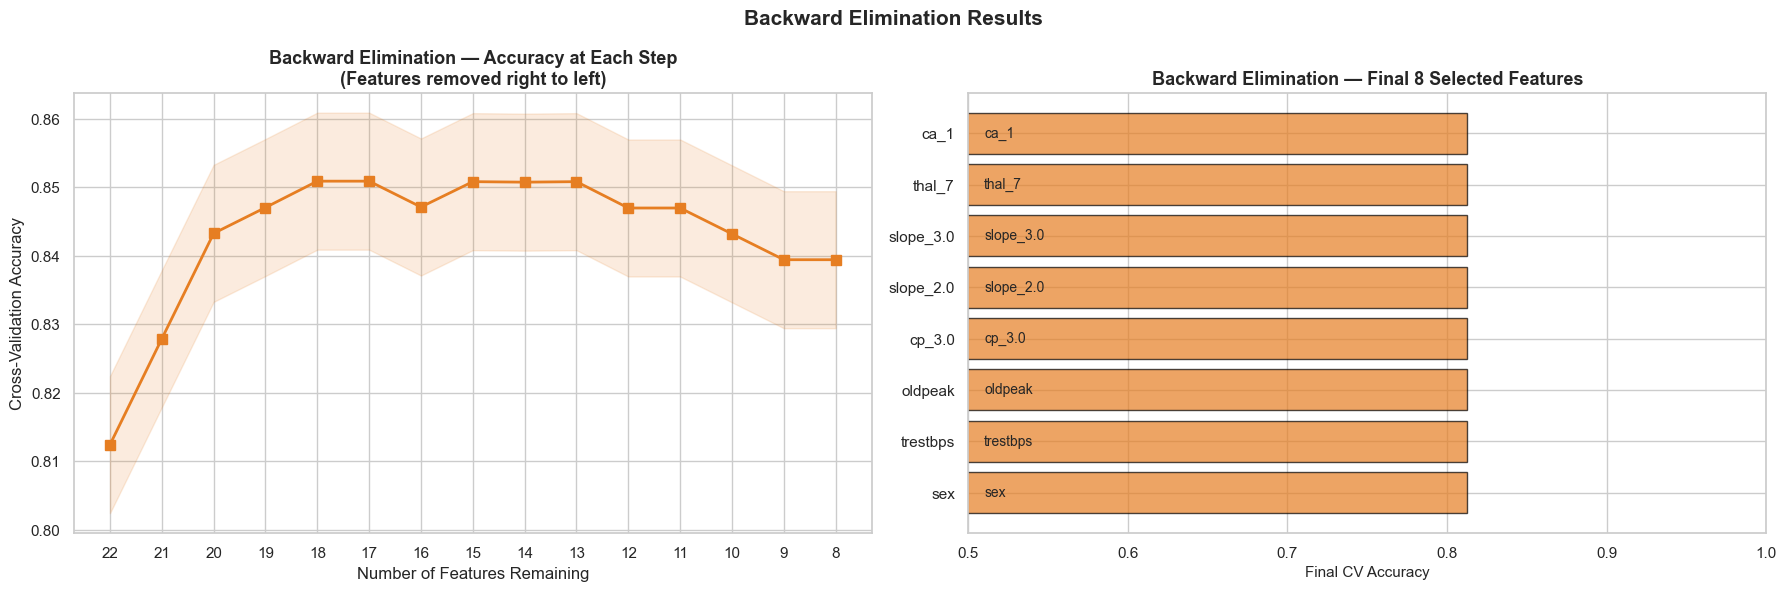

   Backward Elimination visualization saved!


In [12]:
# ============================================================
# CELL 11 — Backward Elimination: Step-by-Step Accuracy Curve
# ============================================================

bwd_steps  = sorted(sfs_bwd.subsets_.keys())
bwd_scores = [sfs_bwd.subsets_[k]['avg_score'] for k in bwd_steps]
bwd_feat_at_step = [list(np.array(feature_names)[list(sfs_bwd.subsets_[k]['feature_idx'])]) for k in bwd_steps]
bwd_removed = []
all_feats = list(feature_names)
prev = set(all_feats)
for step_feats in bwd_feat_at_step:
    removed = prev - set(step_feats)
    bwd_removed.append(list(removed)[0] if removed else '')
    prev = set(step_feats)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Step-by-step accuracy (steps go from many features to few) ---
axes[0].plot(bwd_steps, bwd_scores, marker='s', color='#e67e22', linewidth=2, markersize=7)
axes[0].fill_between(bwd_steps, [s - 0.01 for s in bwd_scores],
                     [s + 0.01 for s in bwd_scores], alpha=0.15, color='#e67e22')
axes[0].invert_xaxis()   # flip so we read left-to-right as features are removed
axes[0].set_xlabel('Number of Features Remaining', fontsize=12)
axes[0].set_ylabel('Cross-Validation Accuracy', fontsize=12)
axes[0].set_title('Backward Elimination — Accuracy at Each Step\n(Features removed right to left)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(bwd_steps)

# --- Plot 2: Final selected features ---
axes[1].barh(bwd_selected_features,
             [bwd_scores[-1]] * len(bwd_selected_features),
             color='#e67e22', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Final CV Accuracy', fontsize=11)
axes[1].set_title(f'Backward Elimination — Final {N_FEATURES} Selected Features',
                  fontsize=13, fontweight='bold')
axes[1].set_xlim(0.5, 1.0)
for i, feat in enumerate(bwd_selected_features):
    axes[1].text(0.51, i, feat, va='center', fontsize=10)

plt.suptitle('Backward Elimination Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wrapper_backward_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Backward Elimination visualization saved!')

---
## Cell 12 — Feature Agreement: What Did All Methods Agree On?

> Here we compare which features were selected by each of the four wrapper methods.
> Features selected by **all four methods** are the most robustly important — they survive
> regardless of the search strategy used.

Feature Agreement Summary
  Features selected by ALL 4 methods   : 2
  → ['sex', 'slope_2.0']
  Features selected by ≥3 methods       : 7
  → ['sex', 'slope_2.0', 'ca_1', 'cp_4.0', 'oldpeak', 'ca_3', 'thal_7']
  Union (selected by any method)        : 20
  → [np.str_('age'), np.str_('ca_1'), np.str_('ca_2'), np.str_('ca_3'), np.str_('chol'), np.str_('cp_2.0'), np.str_('cp_3.0'), np.str_('cp_4.0'), np.str_('exang'), np.str_('fbs'), np.str_('oldpeak'), np.str_('restecg_1.0'), np.str_('restecg_2.0'), np.str_('sex'), np.str_('slope_2.0'), np.str_('slope_3.0'), np.str_('thal_4'), np.str_('thal_7'), np.str_('thalach'), np.str_('trestbps')]


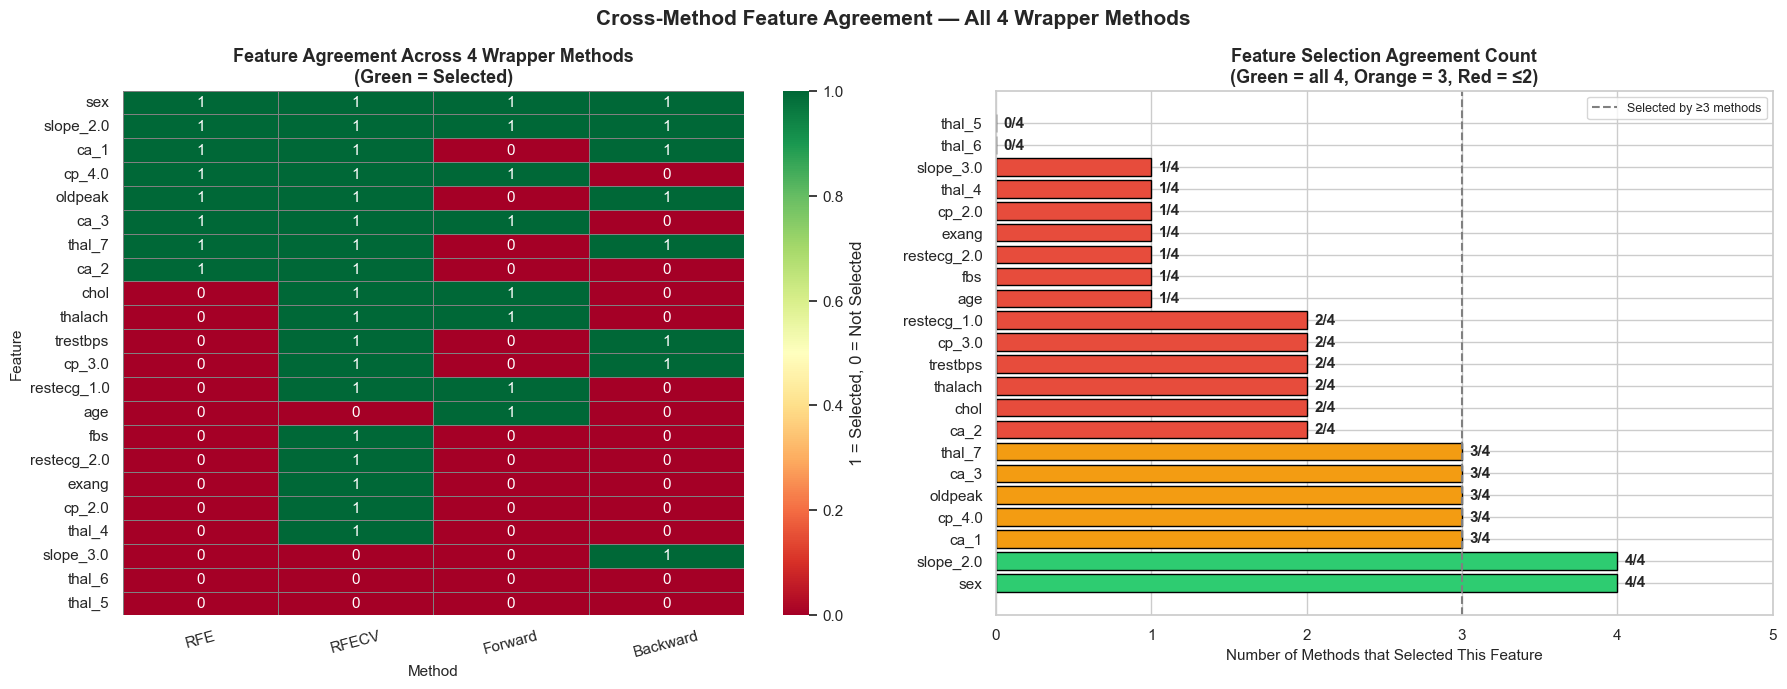

   Agreement heatmap saved!


In [14]:
# ============================================================
# CELL 12 — Feature Agreement Across All 4 Methods
# ============================================================

methods_features = {
    'RFE'       : rfe_features_dict['Logistic Regression'],  # using LR as representative
    'RFECV'     : rfecv_selected_features,
    'Forward'   : fwd_selected_features,
    'Backward'  : bwd_selected_features
}

# Build agreement matrix
agreement_matrix = pd.DataFrame(
    {method: [1 if f in feats else 0 for f in feature_names]
     for method, feats in methods_features.items()},
    index=feature_names
)
agreement_matrix['Agreement Count'] = agreement_matrix.sum(axis=1)
agreement_matrix = agreement_matrix.sort_values('Agreement Count', ascending=False)

# Features selected by ALL 4 methods
all_agree    = list(agreement_matrix[agreement_matrix['Agreement Count'] == 4].index)
# Features selected by at least 3 methods
three_agree  = list(agreement_matrix[agreement_matrix['Agreement Count'] >= 3].index)
# Union of all selected
union_feats  = list(set().union(*methods_features.values()))

print('Feature Agreement Summary')
print('=' * 50)
print(f'  Features selected by ALL 4 methods   : {len(all_agree)}')
print(f'  → {all_agree}')
print(f'  Features selected by ≥3 methods       : {len(three_agree)}')
print(f'  → {three_agree}')
print(f'  Union (selected by any method)        : {len(union_feats)}')
print(f'  → {sorted(union_feats)}')

# --- Visualize agreement heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    agreement_matrix.drop(columns='Agreement Count'),
    ax=axes[0], cmap='RdYlGn', linewidths=0.5,
    linecolor='gray', annot=True, fmt='d',
    cbar_kws={'label': '1 = Selected, 0 = Not Selected'}
)
axes[0].set_title('Feature Agreement Across 4 Wrapper Methods\n(Green = Selected)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Method', fontsize=11)
axes[0].set_ylabel('Feature', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# --- Bar chart of agreement count ---
cnt = agreement_matrix['Agreement Count']
bar_colors = ['#2ecc71' if v == 4 else '#f39c12' if v == 3 else '#e74c3c' for v in cnt.values]
bars = axes[1].barh(cnt.index, cnt.values, color=bar_colors, edgecolor='black')
axes[1].axvline(3, color='gray', linestyle='--', linewidth=1.5, label='Selected by ≥3 methods')
axes[1].set_xlabel('Number of Methods that Selected This Feature', fontsize=11)
axes[1].set_title('Feature Selection Agreement Count\n(Green = all 4, Orange = 3, Red = ≤2)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 5)
for bar, val in zip(bars, cnt.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{int(val)}/4', va='center', fontweight='bold')

plt.suptitle('Cross-Method Feature Agreement — All 4 Wrapper Methods', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wrapper_agreement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Agreement heatmap saved!')

---
## Cell 13 — Full Comparison Table: Baseline vs All 4 Wrapper Methods

> This table brings together the accuracy of all 8 models across the Baseline and
> all 4 wrapper methods. It shows at a glance where each method helped, hurt, or had no effect.

In [16]:
# ============================================================
# CELL 13 — Full Comparison Table
# ============================================================

name_map = {
    'Neural Network (MLP)': 'Neural Network',
    'MLP': 'Neural Network'
}

def fix_keys(d):
    return {name_map.get(k, k): v for k, v in d.items()}

rfe_results    = fix_keys(rfe_results)
rfecv_results  = fix_keys(rfecv_results)
fwd_results    = fix_keys(fwd_results)
bwd_results    = fix_keys(bwd_results)

print("rfe_results keys:", list(rfe_results.keys()))
print("baseline keys   :", list(baseline_results.keys()))

comparison_df = pd.DataFrame({
    'Model'    : list(baseline_results.keys()),
    'Baseline' : [round(baseline_results[m]['Accuracy'], 2) for m in baseline_results.keys()],
    'RFE'      : [round(rfe_results[m] * 100, 2) for m in baseline_results.keys()],
    'RFECV'    : [round(rfecv_results[m] * 100, 2) for m in baseline_results.keys()],
    'Forward'  : [round(fwd_results[m] * 100, 2) for m in baseline_results.keys()],
    'Backward' : [round(bwd_results[m] * 100, 2) for m in baseline_results.keys()]
})
# Add a 'Best Method' column
method_cols = ['RFE', 'RFECV', 'Forward', 'Backward']
comparison_df['Best Method'] = comparison_df[method_cols].idxmax(axis=1)
comparison_df['Best Score']  = comparison_df[method_cols].max(axis=1)
comparison_df['Δ vs Baseline'] = (comparison_df['Best Score'] - comparison_df['Baseline']).round(2)

print('Baseline vs All 4 Wrapper Methods — Accuracy (%)')
print('=' * 80)
print(comparison_df.to_string(index=False))
print('\n  ✅ Improved models:', (comparison_df['Δ vs Baseline'] > 0).sum())
print('  ➖ Same models    :', (comparison_df['Δ vs Baseline'] == 0).sum())
print('  ❌ Declined models:', (comparison_df['Δ vs Baseline'] < 0).sum())

rfe_results keys: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes', 'Neural Network', 'XGBoost']
baseline keys   : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'XGBoost', 'Naive Bayes', 'Neural Network']
Baseline vs All 4 Wrapper Methods — Accuracy (%)
              Model  Baseline   RFE  RFECV  Forward  Backward Best Method  Best Score  Δ vs Baseline
Logistic Regression     85.25 88.52  86.89    75.41     86.89         RFE       88.52           3.27
      Decision Tree     68.85 67.21  77.05    81.97     70.49     Forward       81.97          13.12
      Random Forest     90.16 88.52  90.16    78.69     83.61       RFECV       90.16           0.00
                SVM     90.16 85.25  86.89    78.69     85.25       RFECV       86.89          -3.27
                KNN     85.25 81.97  83.61    77.05     85.25    Backward       85.25           0.00
            XGBoost     86.89 73.77  85.25    78.69     80.33       RFECV    

---
## Cell 14 — Visualization: Baseline vs All 4 Wrapper Methods (Bar Chart)

> This grouped bar chart makes it easy to compare the performance of each model
> across all 5 conditions (Baseline + 4 wrapper methods) side by side.

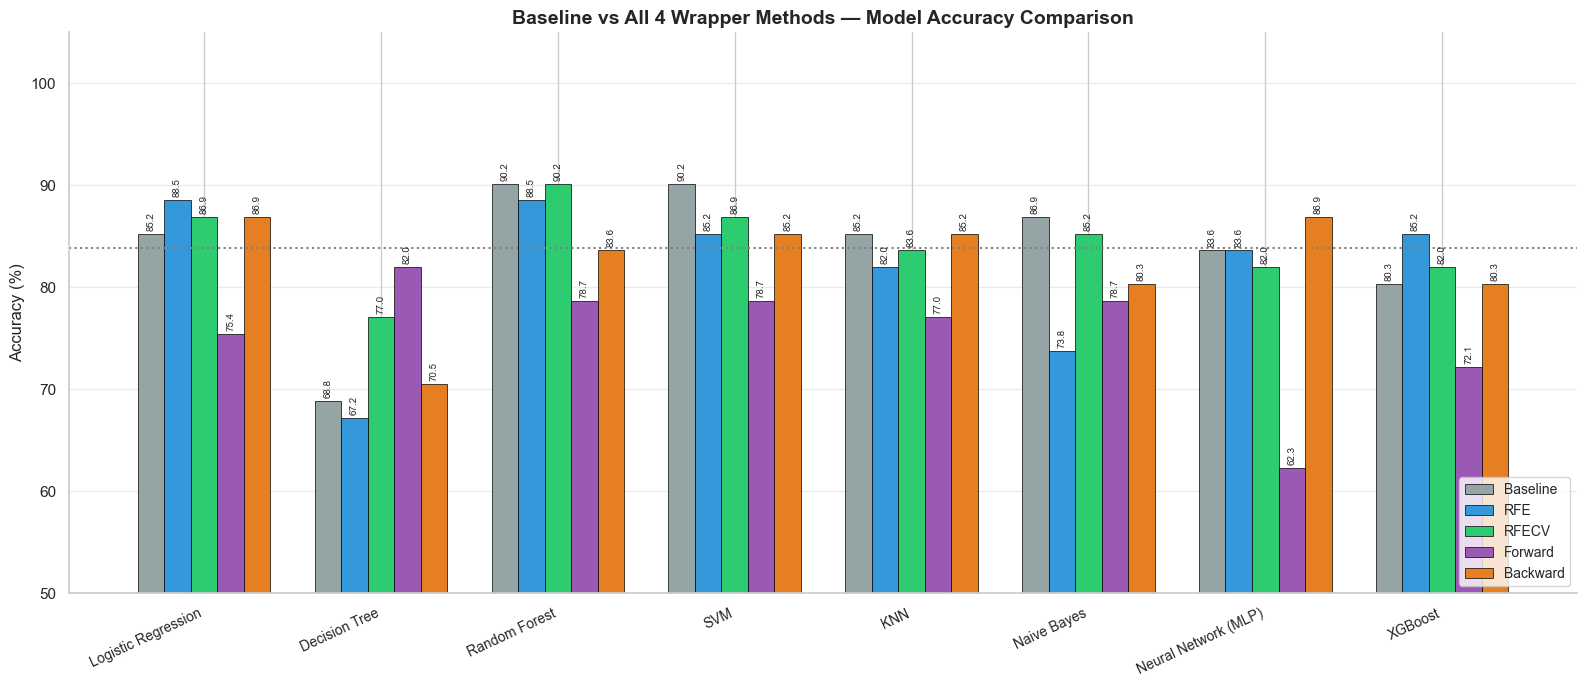

   Grouped bar chart saved!


In [17]:
# ============================================================
# CELL 14 — Grouped Bar Chart: Baseline vs 4 Wrapper Methods
# ============================================================

model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.15
bar_colors = ['#95a5a6', '#3498db', '#2ecc71', '#9b59b6', '#e67e22']
labels     = ['Baseline', 'RFE', 'RFECV', 'Forward', 'Backward']
data_cols  = ['Baseline', 'RFE', 'RFECV', 'Forward', 'Backward']

fig, ax = plt.subplots(figsize=(16, 7))

for i, (col, label, color) in enumerate(zip(data_cols, labels, bar_colors)):
    offset = (i - 2) * width
    bars = ax.bar(x + offset, comparison_df[col], width=width,
                  label=label, color=color, edgecolor='black', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
               f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(50, 105)
ax.set_title('Baseline vs All 4 Wrapper Methods — Model Accuracy Comparison',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.axhline(y=comparison_df['Baseline'].mean(), color='gray',
           linestyle=':', linewidth=1.5, label='Avg Baseline')
ax.grid(axis='y', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.savefig('wrapper_vs_baseline_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Grouped bar chart saved!')

---
## Cell 15 — Heatmap: Full Metrics Comparison

> This heatmap shows Accuracy, Precision, Recall, F1, and AUC for every model
> under the best-performing wrapper method. Darker green = better performance.

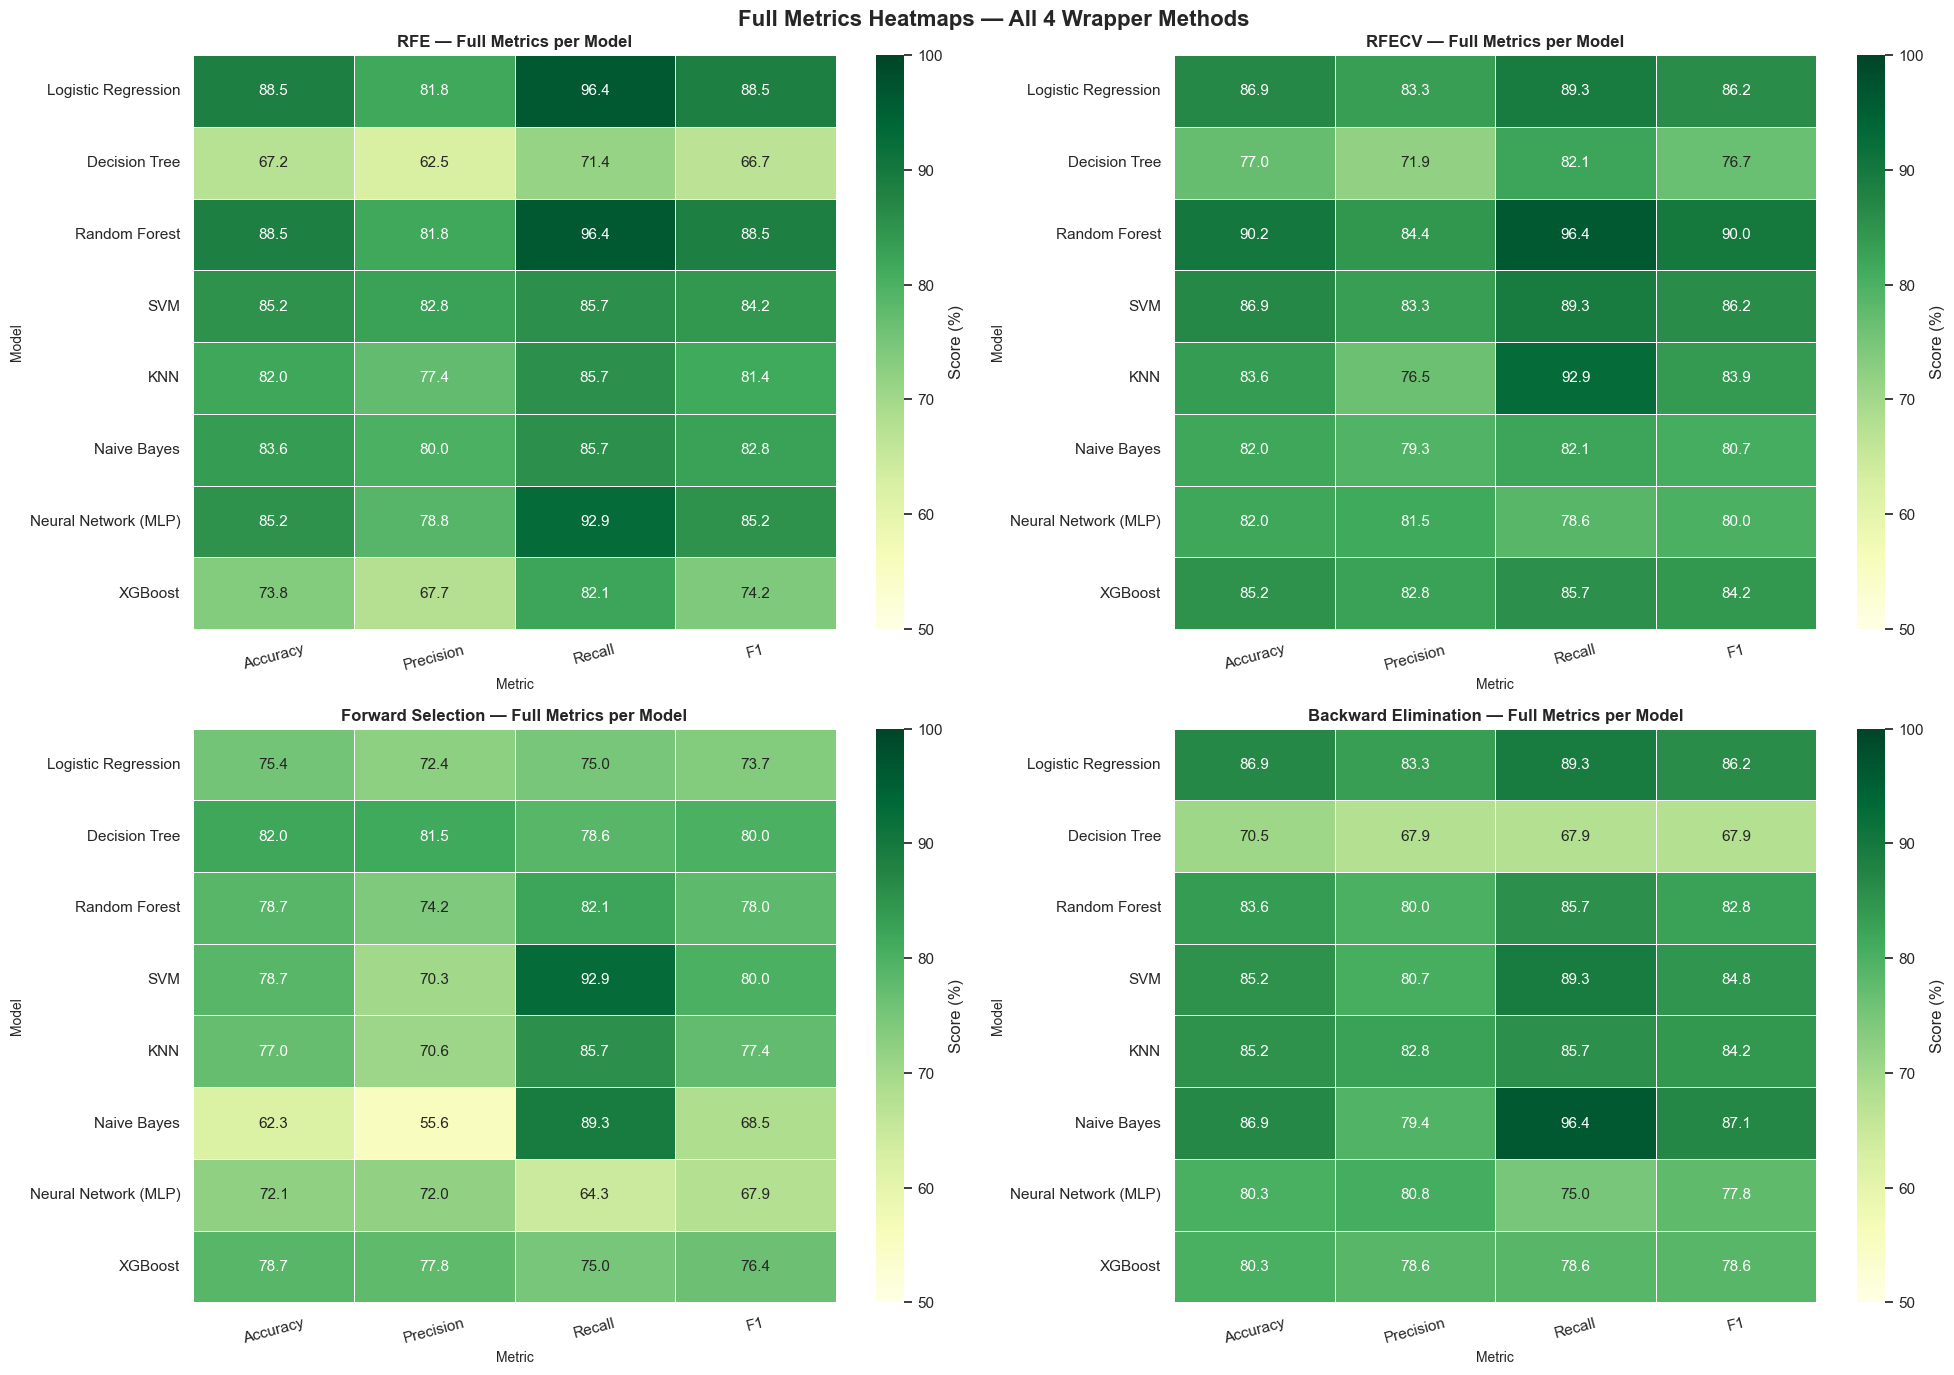

   Heatmaps saved!


In [18]:
# ============================================================
# CELL 15 — Heatmap: Full Metrics for Best Wrapper Method
# ============================================================

# Build a metrics DataFrame for each method
def build_metrics_df(metrics_dict):
    rows = []
    for name, m in metrics_dict.items():
        rows.append({'Model': name, **m})
    return pd.DataFrame(rows).set_index('Model')

metrics_rfe     = build_metrics_df(rfe_metrics_dict).drop(columns='AUC', errors='ignore')
metrics_rfecv   = build_metrics_df(rfecv_metrics_dict).drop(columns='AUC', errors='ignore')
metrics_fwd     = build_metrics_df(fwd_metrics_dict).drop(columns='AUC', errors='ignore')
metrics_bwd     = build_metrics_df(bwd_metrics_dict).drop(columns='AUC', errors='ignore')

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
titles_methods = [
    (metrics_rfe,   'RFE'),
    (metrics_rfecv, 'RFECV'),
    (metrics_fwd,   'Forward Selection'),
    (metrics_bwd,   'Backward Elimination')
]

for ax, (df, title) in zip(axes.flat, titles_methods):
    sns.heatmap(
        df.astype(float), ax=ax,
        annot=True, fmt='.1f', cmap='YlGn',
        vmin=50, vmax=100,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Score (%)'}
    )
    ax.set_title(f'{title} — Full Metrics per Model', fontsize=12, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=10)
    ax.set_ylabel('Model', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Full Metrics Heatmaps — All 4 Wrapper Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wrapper_heatmaps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Heatmaps saved!')

---
## Cell 16 — ROC Curves: Best Wrapper Method

> ROC curves visualize the trade-off between True Positive Rate (sensitivity) and
> False Positive Rate (1 - specificity) for each model.
> A curve closer to the top-left corner means better performance.
> The AUC (Area Under the Curve) summarizes this in a single number — 1.0 is perfect.

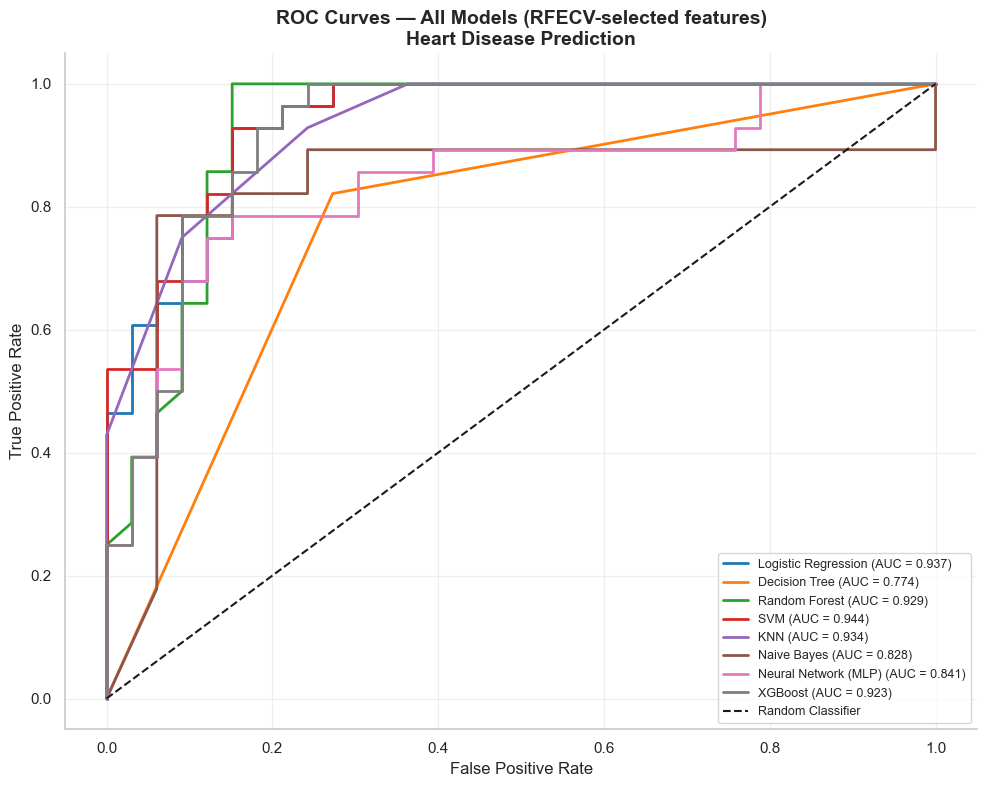

   ROC curves saved!


In [19]:
# ============================================================
# CELL 16 — ROC Curves for All Models (Best Wrapper: RFECV)
# ============================================================

# We plot ROC for RFECV features as the 'CV-optimal' representative
fig, ax = plt.subplots(figsize=(10, 8))
palette = plt.cm.tab10.colors

for i, (name, model) in enumerate(models.items()):
    X_tr = X_train_scaled[rfecv_selected_features] if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_train_raw[rfecv_selected_features]
    X_te = X_test_scaled[rfecv_selected_features]  if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network (MLP)'] else X_test_raw[rfecv_selected_features]

    model.fit(X_tr, y_train)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    else:
        y_proba = model.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score   = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=palette[i], lw=2, label=f'{name} (AUC = {auc_score:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (RFECV-selected features)\nHeart Disease Prediction',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('wrapper_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('   ROC curves saved!')

---
## Cell 17 — Save All Outputs

In [20]:
# ============================================================
# CELL 17 — Save All Outputs
# ============================================================

SAVE_DIR = 'saved_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save selected feature lists
joblib.dump(rfe_features_dict,        f'{SAVE_DIR}/wrapper_rfe_features.pkl')
joblib.dump(rfecv_selected_features,  f'{SAVE_DIR}/wrapper_rfecv_features.pkl')
joblib.dump(fwd_selected_features,    f'{SAVE_DIR}/wrapper_forward_features.pkl')
joblib.dump(bwd_selected_features,    f'{SAVE_DIR}/wrapper_backward_features.pkl')
print('  ✅ wrapper_rfe_features.pkl       → RFE selected features per model')
print('  ✅ wrapper_rfecv_features.pkl     → RFECV selected features')
print('  ✅ wrapper_forward_features.pkl   → Forward selection features')
print('  ✅ wrapper_backward_features.pkl  → Backward elimination features')

# Save results dictionaries
joblib.dump(rfe_results,   f'{SAVE_DIR}/wrapper_results_rfe.pkl')
joblib.dump(rfecv_results, f'{SAVE_DIR}/wrapper_results_rfecv.pkl')
joblib.dump(fwd_results,   f'{SAVE_DIR}/wrapper_results_forward.pkl')
joblib.dump(bwd_results,   f'{SAVE_DIR}/wrapper_results_backward.pkl')
print('  ✅ wrapper_results_rfe.pkl        → RFE accuracy per model')
print('  ✅ wrapper_results_rfecv.pkl      → RFECV accuracy per model')
print('  ✅ wrapper_results_forward.pkl    → Forward accuracy per model')
print('  ✅ wrapper_results_backward.pkl   → Backward accuracy per model')

# Save comparison table as CSV
comparison_df.to_csv(f'{SAVE_DIR}/wrapper_comparison.csv', index=False)
print('  ✅ wrapper_comparison.csv         → Baseline vs Wrapper comparison table')

print(f'\n  ✅ All outputs saved to: {SAVE_DIR}/')

  ✅ wrapper_rfe_features.pkl       → RFE selected features per model
  ✅ wrapper_rfecv_features.pkl     → RFECV selected features
  ✅ wrapper_forward_features.pkl   → Forward selection features
  ✅ wrapper_backward_features.pkl  → Backward elimination features
  ✅ wrapper_results_rfe.pkl        → RFE accuracy per model
  ✅ wrapper_results_rfecv.pkl      → RFECV accuracy per model
  ✅ wrapper_results_forward.pkl    → Forward accuracy per model
  ✅ wrapper_results_backward.pkl   → Backward accuracy per model
  ✅ wrapper_comparison.csv         → Baseline vs Wrapper comparison table

  ✅ All outputs saved to: saved_data/


---
## Cell 18 — Final Summary Report

In [ ]:
# ============================================================
# CELL 18 — Final Summary Report
# ============================================================

improved  = (comparison_df['Δ vs Baseline'] > 0).sum()
declined  = (comparison_df['Δ vs Baseline'] < 0).sum()
same      = (comparison_df['Δ vs Baseline'] == 0).sum()

# Best method overall (highest avg accuracy)
avg_acc = {col: comparison_df[col].mean() for col in ['RFE', 'RFECV', 'Forward', 'Backward']}
best_method = max(avg_acc, key=avg_acc.get)

print('=' * 65)
print('       WRAPPER FEATURE SELECTION — SUMMARY REPORT')
print('    Heart Disease Prediction — UCI Cleveland Dataset')
print('=' * 65)

print(f'\n  INPUT:')
print(f'    Total features (after encoding) : {len(feature_names)}')
print(f'    Training samples                : {X_train_scaled.shape[0]}')
print(f'    Test samples                    : {X_test_scaled.shape[0]}')

print(f'\n  METHOD 1 — RFE (Recursive Feature Elimination):')
print(f'    Target features : {N_FEATURES}')
print(f'    Avg accuracy    : {np.mean(list(rfe_results.values()))*100:.2f}%')

print(f'\n  METHOD 2 — RFECV (RFE with Cross-Validation):')
print(f'    Optimal features: {rfecv_n_features}')
print(f'    → {rfecv_selected_features}')
print(f'    Avg accuracy    : {np.mean(list(rfecv_results.values()))*100:.2f}%')

print(f'\n  METHOD 3 — Forward Selection:')
print(f'    Selected {len(fwd_selected_features)} features: {fwd_selected_features}')
print(f'    Avg accuracy    : {np.mean(list(fwd_results.values()))*100:.2f}%')

print(f'\n  METHOD 4 — Backward Elimination:')
print(f'    Selected {len(bwd_selected_features)} features: {bwd_selected_features}')
print(f'    Avg accuracy    : {np.mean(list(bwd_results.values()))*100:.2f}%')

print(f'\n  FEATURE AGREEMENT:')
print(f'    Selected by ALL 4 methods       : {all_agree}')
print(f'    Selected by ≥3 methods          : {three_agree}')

print(f'\n  BEST WRAPPER METHOD OVERALL: {best_method} (avg acc = {avg_acc[best_method]:.2f}%)')
for m, a in avg_acc.items():
    print(f'    {m:12s} avg acc : {a:.2f}%')

print(f'\n  COMPARISON vs BASELINE:')
print(f'    Models improved : {improved}')
print(f'    Models declined : {declined}')
print(f'    Models unchanged: {same}')

print(f'\n  PLOTS SAVED:')
print(f'    → wrapper_rfe_heatmap.png')
print(f'    → wrapper_rfecv_curve.png')
print(f'    → wrapper_forward_curve.png')
print(f'    → wrapper_backward_curve.png')
print(f'    → wrapper_agreement_heatmap.png')
print(f'    → wrapper_vs_baseline_barchart.png')
print(f'    → wrapper_heatmaps_comparison.png')
print(f'    → wrapper_roc_curves.png')

print()
print('=' * 65)
print('  ✅ Wrapper Feature Selection Complete!')
print('=' * 65)